In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

from pathlib import Path
import random
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_CROPS = PROJECT_ROOT / "data" / "crops"
RUNS_BASE = PROJECT_ROOT / "runs"

DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print("device:", DEVICE)
print("img size:", IMG_SIZE)


device: mps
img size: 224


In [2]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_ds = ImageFolder(DATA_CROPS / "train", transform=train_transform)
val_ds = ImageFolder(DATA_CROPS / "val", transform=eval_transform)
test_ds = ImageFolder(DATA_CROPS / "test", transform=eval_transform)
classes = train_ds.classes
print("classes:", classes)
print(f"train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")


classes: ['cattle', 'sheep']
train: 35806, val: 7770, test: 7744


In [3]:
def make_resnet50(dropout=0.3):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    for p in model.parameters():
        p.requires_grad = False
    in_f = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_f, 128),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(128, 2),
    )
    return model


def make_vgg16(dropout=0.3):
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    for p in model.parameters():
        p.requires_grad = False
    model.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(512 * 7 * 7, 128),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(128, 2),
    )
    return model


def make_mobilenet_v2(dropout=0.3):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
    for p in model.parameters():
        p.requires_grad = False
    in_f = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_f, 128),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(128, 2),
    )
    return model


MODEL_FACTORIES = {
    "resnet50": make_resnet50,
    "vgg16": make_vgg16,
    "mobilenet_v2": make_mobilenet_v2,
}


for name, factory in MODEL_FACTORIES.items():
    m = factory()
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{name}: total={total:,} trainable={trainable:,} ({100*trainable/total:.2f}%)")


resnet50: total=23,770,562 trainable=262,530 (1.10%)


vgg16: total=17,926,338 trainable=3,211,650 (17.92%)
mobilenet_v2: total=2,388,098 trainable=164,226 (6.88%)


In [4]:
def make_optimizer(name, params, lr, weight_decay=0.0):
    trainable = [p for p in params if p.requires_grad]
    if name == "adam":
        return torch.optim.Adam(trainable, lr=lr, weight_decay=weight_decay)
    if name == "adamw":
        return torch.optim.AdamW(trainable, lr=lr, weight_decay=weight_decay)
    return torch.optim.SGD(trainable, lr=lr, momentum=0.9, weight_decay=weight_decay)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        total_correct += (out.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, total_correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    ys, ps = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            loss = criterion(out, labels)
            total_loss += loss.item() * imgs.size(0)
            ys.extend(labels.cpu().numpy().tolist())
            ps.extend(out.argmax(1).cpu().numpy().tolist())
    acc = accuracy_score(ys, ps)
    return total_loss / len(loader.dataset), acc, np.array(ys), np.array(ps)


def fit_model(model, tr_loader, val_loader, epochs, optimizer, criterion, device, patience=4, verbose=False):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val, best_state, patience_n = 0.0, None, 0
    for epoch in range(epochs):
        t0 = time.time()
        tl, ta = train_one_epoch(model, tr_loader, optimizer, criterion, device)
        vl, va, _, _ = evaluate(model, val_loader, criterion, device)
        history["train_loss"].append(tl)
        history["train_acc"].append(ta)
        history["val_loss"].append(vl)
        history["val_acc"].append(va)
        if verbose:
            print(f"  epoch {epoch+1}: train_acc={ta:.4f} val_acc={va:.4f} ({time.time()-t0:.1f}s)")
        if va > best_val:
            best_val = va
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_n = 0
        else:
            patience_n += 1
            if patience_n >= patience:
                if verbose:
                    print(f"  early stop at epoch {epoch+1}")
                break
    return history, best_state, best_val


print("utilities ready")


utilities ready


In [5]:
SUBSET_TRAIN = 3000
SUBSET_VAL = 600
HP_EPOCHS = 3
HP_TRIALS = 6

rng = np.random.RandomState(SEED)
sub_train_idx = rng.choice(len(train_ds), size=SUBSET_TRAIN, replace=False).tolist()
sub_val_idx = rng.choice(len(val_ds), size=SUBSET_VAL, replace=False).tolist()
sub_train = Subset(train_ds, sub_train_idx)
sub_val = Subset(val_ds, sub_val_idx)
print(f"subset train={len(sub_train)}, val={len(sub_val)}")


def objective_for(backbone_name):
    factory = MODEL_FACTORIES[backbone_name]

    def objective(trial):
        lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
        wd = trial.suggest_float("weight_decay", 0.0, 1e-3)
        dropout = trial.suggest_float("dropout", 0.1, 0.5)
        bs = trial.suggest_categorical("batch_size", [16, 32, 64])
        opt = trial.suggest_categorical("optimizer", ["adam", "adamw"])

        model = factory(dropout=dropout).to(DEVICE)
        optimizer = make_optimizer(opt, model.parameters(), lr, weight_decay=wd)
        criterion = nn.CrossEntropyLoss()
        tr = DataLoader(sub_train, batch_size=bs, shuffle=True, num_workers=0)
        va = DataLoader(sub_val, batch_size=bs, shuffle=False, num_workers=0)
        _, _, best = fit_model(model, tr, va, HP_EPOCHS, optimizer, criterion, DEVICE, patience=2)
        return best

    return objective


print("objective builder ready")


subset train=3000, val=600
objective builder ready


In [6]:
studies = {}
for name in ("resnet50", "vgg16", "mobilenet_v2"):
    run_dir = RUNS_BASE / name
    run_dir.mkdir(parents=True, exist_ok=True)
    print(f"\n=== HP search for {name} ===")
    sampler = TPESampler(seed=SEED)
    study = optuna.create_study(
        direction="maximize",
        sampler=sampler,
        study_name=f"{name}_transfer",
        storage=f"sqlite:///{run_dir / 'optuna.db'}",
        load_if_exists=True,
    )
    t0 = time.time()
    study.optimize(objective_for(name), n_trials=HP_TRIALS, show_progress_bar=False)
    print(f"done in {time.time()-t0:.1f}s; best val acc: {study.best_value:.4f}")
    print(f"best params: {study.best_params}")
    studies[name] = study



=== HP search for resnet50 ===


[I 2026-04-23 18:12:41,947] Using an existing study with name 'resnet50_transfer' instead of creating a new one.


[I 2026-04-23 18:14:19,905] Trial 6 finished with value: 0.9033333333333333 and parameters: {'lr': 5.6115164153345e-05, 'weight_decay': 0.0009507143064099162, 'dropout': 0.39279757672456206, 'batch_size': 16, 'optimizer': 'adamw'}. Best is trial 1 with value: 0.9183333333333333.


[I 2026-04-23 18:16:37,089] Trial 7 finished with value: 0.9183333333333333 and parameters: {'lr': 0.00015930522616241006, 'weight_decay': 0.0007080725777960455, 'dropout': 0.10823379771832098, 'batch_size': 16, 'optimizer': 'adamw'}. Best is trial 1 with value: 0.9183333333333333.


[I 2026-04-23 18:18:40,120] Trial 8 finished with value: 0.8883333333333333 and parameters: {'lr': 4.059611610484306e-05, 'weight_decay': 0.0005247564316322379, 'dropout': 0.2727780074568463, 'batch_size': 32, 'optimizer': 'adamw'}. Best is trial 1 with value: 0.9183333333333333.


...

[I 2026-04-23 18:45:43,817] Trial 8 finished with value: 0.855 and parameters: {'lr': 4.059611610484306e-05, 'weight_decay': 0.0005247564316322379, 'dropout': 0.2727780074568463, 'batch_size': 32, 'optimizer': 'adamw'}. Best is trial 1 with value: 0.8966666666666666.


[I 2026-04-23 18:46:28,303] Trial 9 finished with value: 0.89 and parameters: {'lr': 8.168455894760161e-05, 'weight_decay': 0.0007851759613930136, 'dropout': 0.1798695128633439, 'batch_size': 32, 'optimizer': 'adam'}. Best is trial 1 with value: 0.8966666666666666.


[I 2026-04-23 18:47:11,319] Trial 10 finished with value: 0.89 and parameters: {'lr': 0.0006038889580599074, 'weight_decay': 5.997182955817478e-06, 'dropout': 0.20340815903401854, 'batch_size': 64, 'optimizer': 'adam'}. Best is trial 1 with value: 0.8966666666666666.


[I 2026-04-23 18:47:54,499] Trial 11 finished with value: 0.865 and parameters: {'lr': 0.00022431069969720084, 'weight_decay': 0.00075160019384588, 'dropout': 0.17818220701568344, 'batch_size': 64, 'optimizer': 'adam'}. Best is trial 1 with value: 0.8966666666666666.


done in 270.8s; best val acc: 0.8967
best params: {'lr': 0.00015930522616241006, 'weight_decay': 0.0007080725777960455, 'dropout': 0.10823379771832098, 'batch_size': 16, 'optimizer': 'adamw'}


In [7]:
print("HP summary across all transfer models")
print()
summary_rows = []
for name, study in studies.items():
    row = {"model": name, "best_val_acc": study.best_value, **study.best_params}
    summary_rows.append(row)
    print(f"{name}: val_acc={study.best_value:.4f}")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")
    print()

hp_summary_df = pd.DataFrame(summary_rows)
print(hp_summary_df.to_string(index=False))


HP summary across all transfer models

resnet50: val_acc=0.9267
  lr: 0.0006548373730929827
  weight_decay: 1.5594799658456382e-05
  dropout: 0.1978761396414842
  batch_size: 64
  optimizer: adam

vgg16: val_acc=0.9550
  lr: 0.00015930522616241006
  weight_decay: 0.0007080725777960455
  dropout: 0.10823379771832098
  batch_size: 16
  optimizer: adamw

mobilenet_v2: val_acc=0.8967
  lr: 0.00015930522616241006
  weight_decay: 0.0007080725777960455
  dropout: 0.10823379771832098
  batch_size: 16
  optimizer: adamw

       model  best_val_acc       lr  weight_decay  dropout  batch_size optimizer
    resnet50      0.926667 0.000655      0.000016 0.197876          64      adam
       vgg16      0.955000 0.000159      0.000708 0.108234          16     adamw
mobilenet_v2      0.896667 0.000159      0.000708 0.108234          16     adamw



=== resnet50 ===
loading cached results and weights


resnet50 test: acc=0.9570 P=0.9567 R=0.9570 F1=0.9568


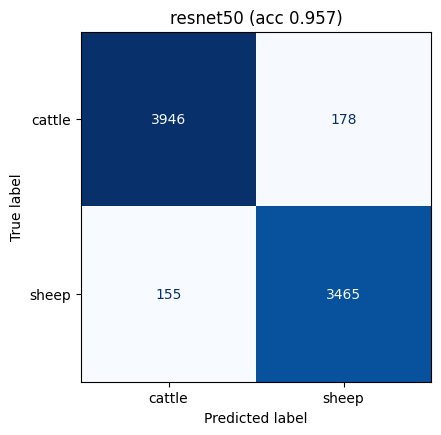


=== vgg16 ===
loading cached results and weights


vgg16 test: acc=0.9738 P=0.9744 R=0.9730 F1=0.9736


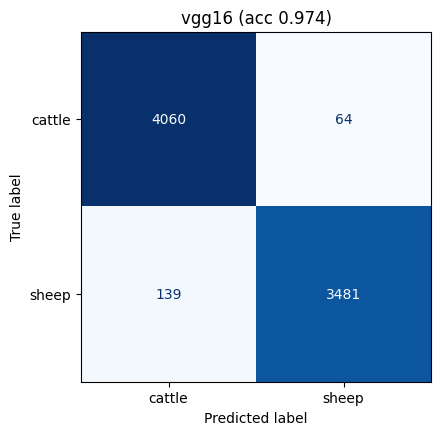


=== mobilenet_v2 ===
loading cached results and weights


mobilenet_v2 test: acc=0.9498 P=0.9496 R=0.9495 F1=0.9496


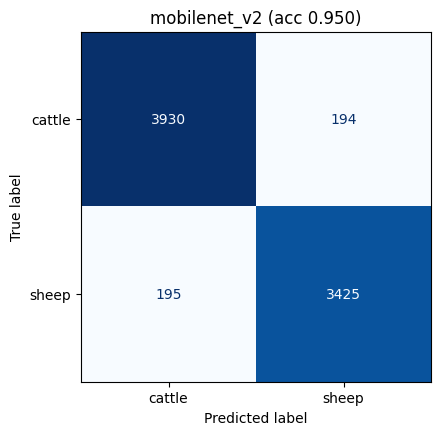

In [8]:
FINAL_EPOCHS = 10
criterion = nn.CrossEntropyLoss()

final_results = {}

for name, study in studies.items():
    print(f"\n=== {name} ===")
    run_dir = RUNS_BASE / name
    bp = study.best_params
    results_path = run_dir / "test_results.json"
    weights_path = run_dir / f"best_{name}.pt"

    if results_path.exists() and weights_path.exists():
        print(f"loading cached results and weights")
        with open(results_path) as f:
            result = json.load(f)
        model = MODEL_FACTORIES[name](dropout=bp["dropout"]).to(DEVICE)
        model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
        ys = np.load(run_dir / "test_ys.npy")
        ps = np.load(run_dir / "test_ps.npy")
        test_acc = result["test_acc"]
        best_val = result["best_val_acc"]
        cm = np.array(result["confusion_matrix"])
    else:
        model = MODEL_FACTORIES[name](dropout=bp["dropout"]).to(DEVICE)
        optimizer = make_optimizer(bp["optimizer"], model.parameters(),
                                    bp["lr"], weight_decay=bp["weight_decay"])
        tr_loader = DataLoader(train_ds, batch_size=bp["batch_size"], shuffle=True, num_workers=0)
        val_loader = DataLoader(val_ds, batch_size=bp["batch_size"], shuffle=False, num_workers=0)
        t0 = time.time()
        history, best_state, best_val = fit_model(
            model, tr_loader, val_loader, FINAL_EPOCHS, optimizer, criterion, DEVICE,
            patience=4, verbose=True,
        )
        print(f"total final train time: {(time.time()-t0)/60:.1f} min")
        model.load_state_dict(best_state)
        torch.save(best_state, weights_path)

        test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0)
        _, test_acc, ys, ps = evaluate(model, test_loader, criterion, DEVICE)
        p_macro = precision_score(ys, ps, average="macro")
        r_macro = recall_score(ys, ps, average="macro")
        f1_macro = f1_score(ys, ps, average="macro")
        cm = confusion_matrix(ys, ps)

        result = {
            "model": name,
            "best_val_acc": float(best_val),
            "test_acc": float(test_acc),
            "precision": float(p_macro),
            "recall": float(r_macro),
            "f1": float(f1_macro),
            "confusion_matrix": cm.tolist(),
            "best_params": bp,
            "n_params_total": sum(p.numel() for p in model.parameters()),
            "n_params_trainable": sum(p.numel() for p in model.parameters() if p.requires_grad),
        }
        with open(results_path, "w") as f:
            json.dump(result, f, indent=2)
        np.save(run_dir / "test_ys.npy", ys)
        np.save(run_dir / "test_ps.npy", ps)

    print(f"{name} test: acc={test_acc:.4f} P={result['precision']:.4f} R={result['recall']:.4f} F1={result['f1']:.4f}")

    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name} (acc {test_acc:.3f})")
    plt.tight_layout()
    plt.savefig(run_dir / "confusion_matrix.png", dpi=100, bbox_inches="tight")
    plt.show()

    final_results[name] = {"test_acc": test_acc, "result": result, "model": model}


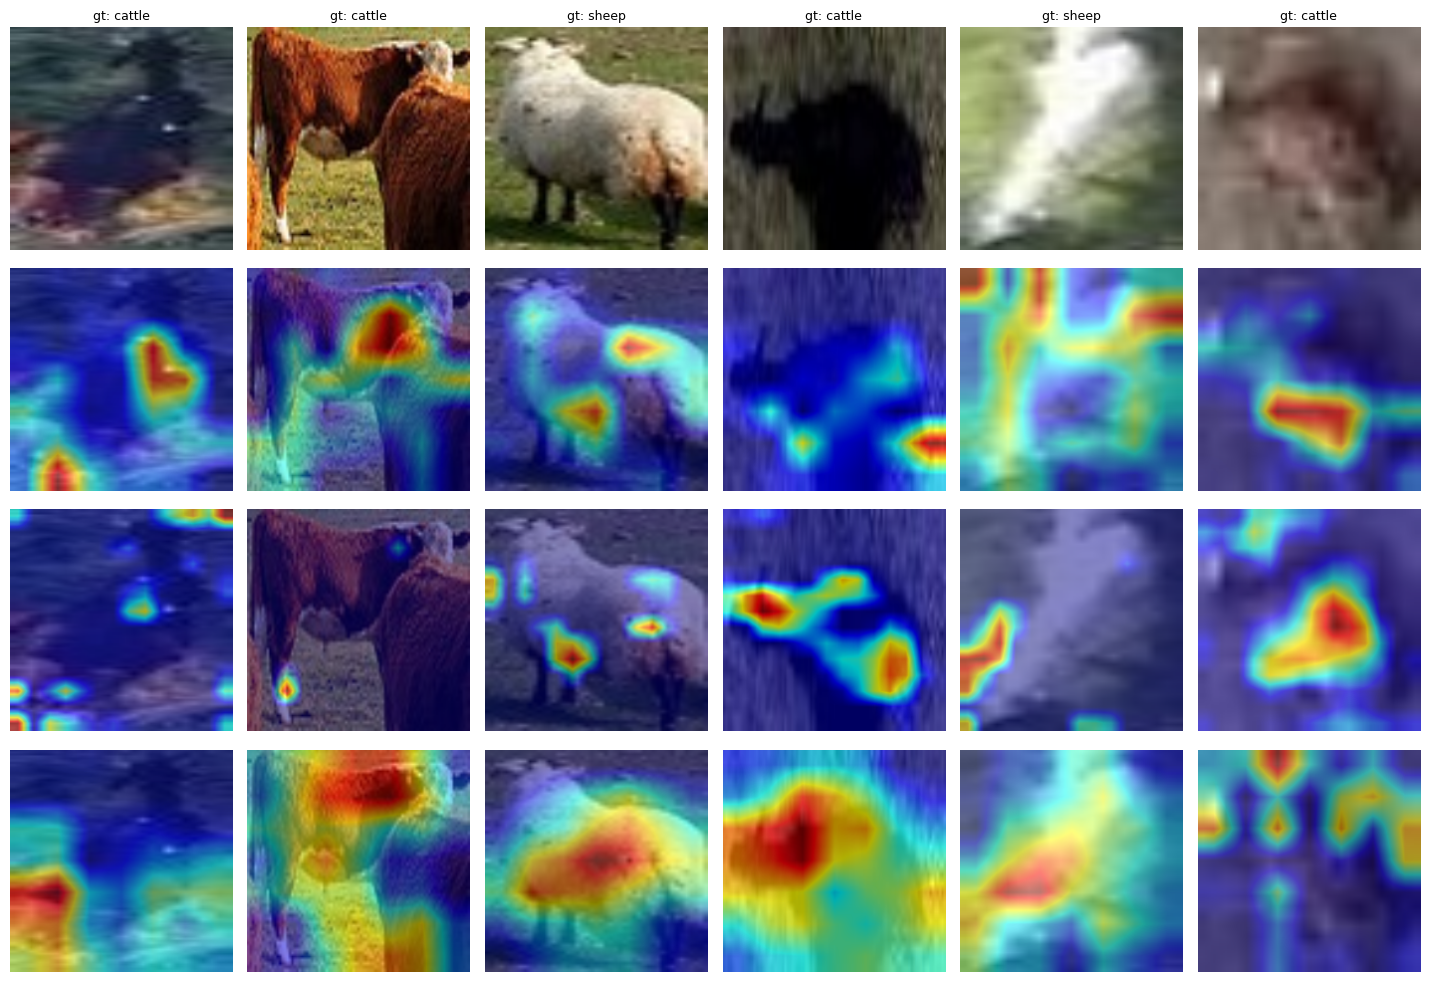

saved transfer_gradcam_grid.png


In [9]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

GRAD_CAM_LAYER = {
    "resnet50": lambda m: [m.layer4[-1]],
    "vgg16": lambda m: [m.features[-3]],
    "mobilenet_v2": lambda m: [m.features[-1]],
}

n_samples = 6
sample_indices = np.random.RandomState(SEED).choice(len(test_ds), size=n_samples, replace=False)
mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std_t = torch.tensor(IMAGENET_STD).view(3, 1, 1)

fig, axes = plt.subplots(4, n_samples, figsize=(n_samples * 2.4, 10))
for i, idx in enumerate(sample_indices):
    img_tensor, label = test_ds[idx]
    img_rgb = (img_tensor * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(f"gt: {classes[label]}", fontsize=9)
    axes[0, i].axis("off")

for row_idx, name in enumerate(("resnet50", "vgg16", "mobilenet_v2")):
    model = final_results[name]["model"]
    for p in model.parameters():
        p.requires_grad_(True)
    model.eval()
    target_layers = GRAD_CAM_LAYER[name](model)
    cam = GradCAM(model=model, target_layers=target_layers)
    for i, idx in enumerate(sample_indices):
        img_tensor, label = test_ds[idx]
        img_rgb = (img_tensor * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
        grayscale = cam(input_tensor=img_tensor.unsqueeze(0).to(DEVICE))[0]
        viz = show_cam_on_image(img_rgb, grayscale, use_rgb=True)
        axes[row_idx + 1, i].imshow(viz)
        axes[row_idx + 1, i].axis("off")
        if i == 0:
            axes[row_idx + 1, 0].set_ylabel(name, rotation=90, labelpad=10)

plt.tight_layout()
plt.savefig(RUNS_BASE / "transfer_gradcam_grid.png", dpi=100, bbox_inches="tight")
plt.show()
print("saved transfer_gradcam_grid.png")


In [10]:
summary_rows = []
for name, r in final_results.items():
    res = r["result"]
    summary_rows.append({
        "model": name,
        "total_params": res["n_params_total"],
        "trainable_params": res["n_params_trainable"],
        "best_val_acc": round(res["best_val_acc"], 4),
        "test_acc": round(res["test_acc"], 4),
        "precision": round(res["precision"], 4),
        "recall": round(res["recall"], 4),
        "f1": round(res["f1"], 4),
    })

baseline_path = RUNS_BASE / "baseline_cnn" / "test_results.json"
if baseline_path.exists():
    with open(baseline_path) as f:
        baseline = json.load(f)
    summary_rows.insert(0, {
        "model": "custom_cnn",
        "total_params": 8760706,
        "trainable_params": 8760706,
        "best_val_acc": round(baseline["best_val_acc"], 4),
        "test_acc": round(baseline["test_acc"], 4),
        "precision": round(baseline["precision"], 4),
        "recall": round(baseline["recall"], 4),
        "f1": round(baseline["f1"], 4),
    })

comp_df = pd.DataFrame(summary_rows)
print("classification models comparison (custom CNN baseline + transfer learning):")
print()
print(comp_df.to_string(index=False))

comp_df.to_csv(RUNS_BASE / "classification_comparison.csv", index=False)
print()
print("saved", RUNS_BASE / "classification_comparison.csv")


classification models comparison (custom CNN baseline + transfer learning):

       model  total_params  trainable_params  best_val_acc  test_acc  precision  recall     f1
  custom_cnn       8760706           8760706        0.9609    0.9610     0.9610  0.9606 0.9608
    resnet50      23770562            262530        0.9565    0.9570     0.9567  0.9570 0.9568
       vgg16      17926338           3211650        0.9722    0.9738     0.9744  0.9730 0.9736
mobilenet_v2       2388098            164226        0.9484    0.9498     0.9496  0.9495 0.9496

saved /Users/m/Documents/capstone-msc-da-feb-25-cohort-MeerimZhenisbekova/runs/classification_comparison.csv
